# 1. **EDA**

=== 5 Baris Pertama ===
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

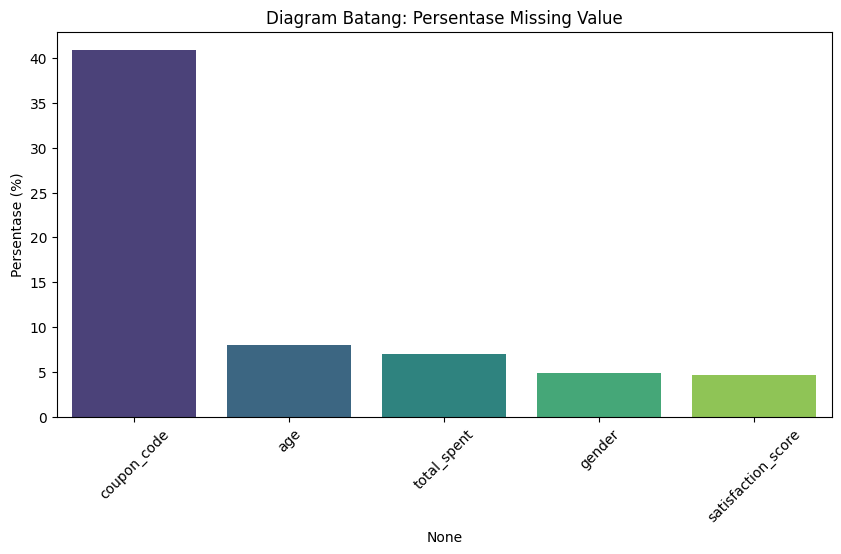


=== Visualisasi Keseimbangan Kelas Target (Churn) ===


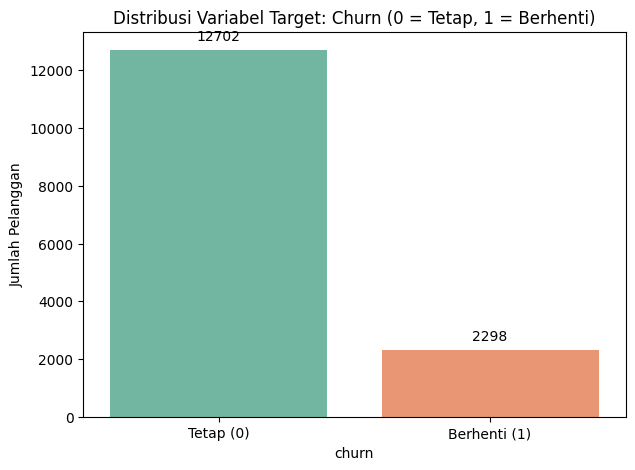


=== Heatmap Korelasi Fitur Numerik ===


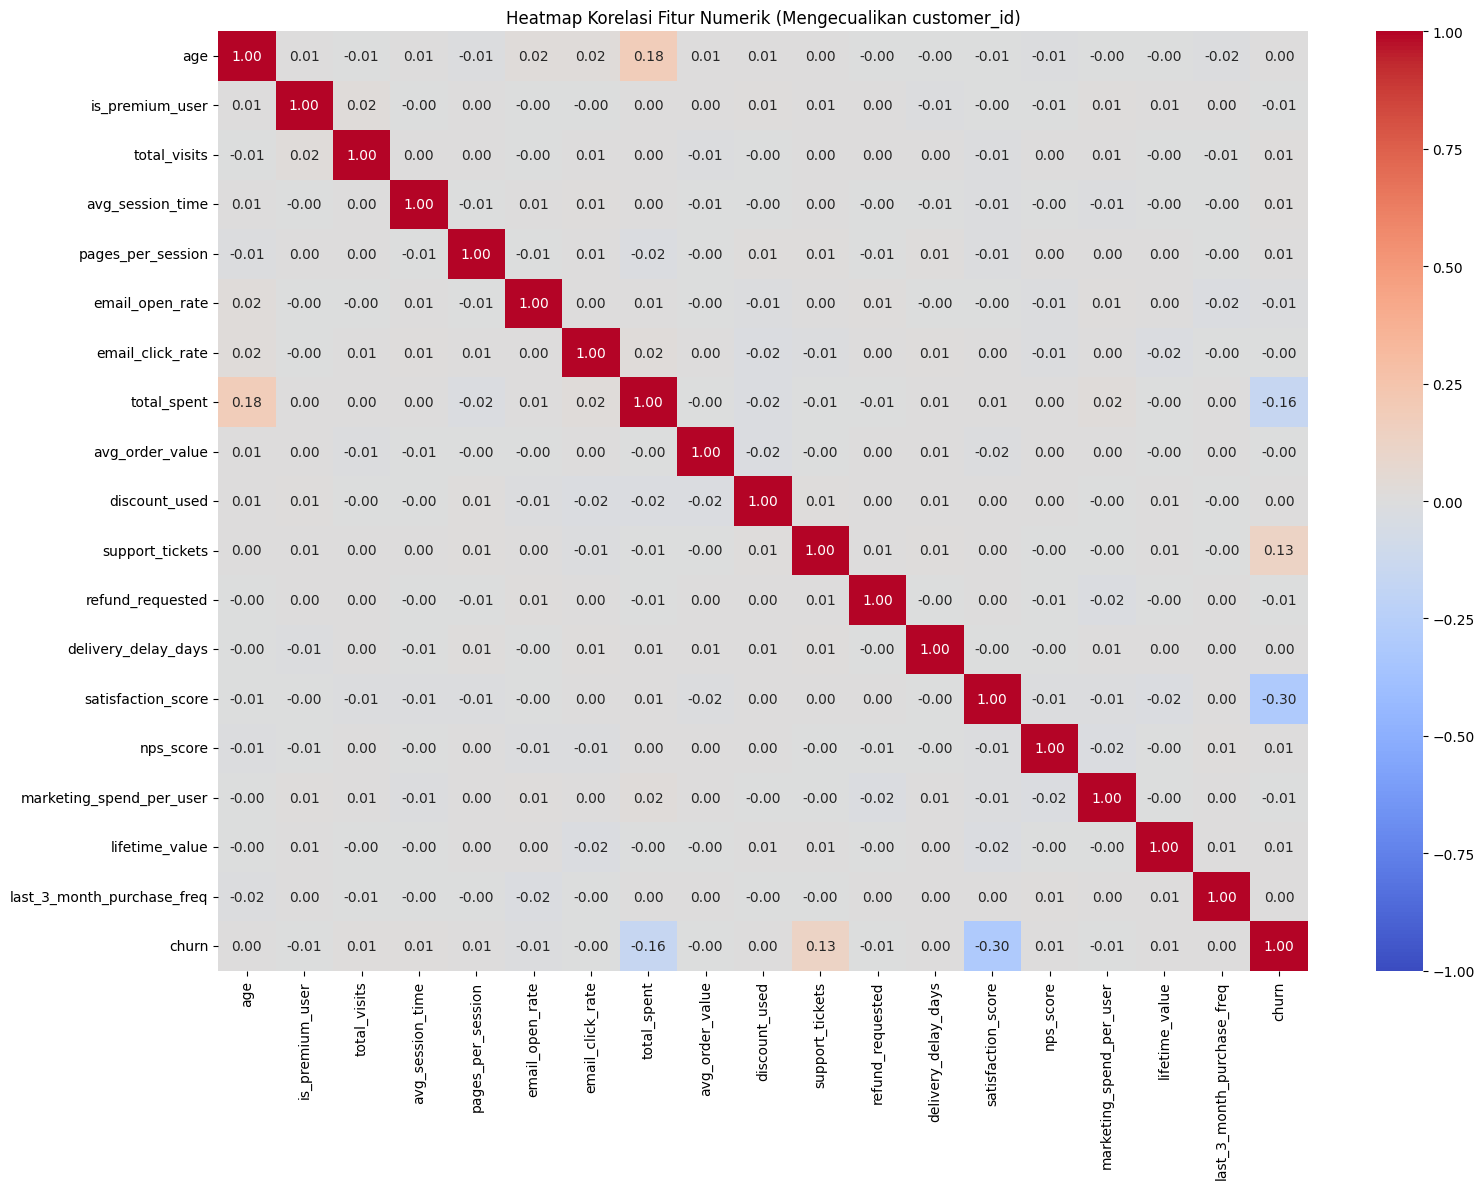

In [1]:
#EDA
#  Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# 2. Tampilkan 5 Baris Pertama, Info, dan Statistik Deskriptif
print("=== 5 Baris Pertama ===")
print(df.head())

print("\n=== Informasi Dataset ===")
print(df.info())

print("\n=== Statistik Deskriptif ===")
print(df.describe())


# 3. Identifikasi & Visualisasi Missing Value
# Hitung persentase nilai kosong
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("\n=== Persentase Missing Values per Kolom (%) ===")
print(missing_df)

# Visualisasi Diagram Batang untuk Missing Value
if not missing_df.empty:
    plt.figure(figsize=(10, 5))
    #Menambahkan hue dan legend=False untuk menghindari FutureWarning
    sns.barplot(x=missing_df.index, y=missing_df.values, hue=missing_df.index, palette='viridis', legend=False)
    plt.xticks(rotation=45)
    plt.title('Diagram Batang: Persentase Missing Value')
    plt.ylabel('Persentase (%)')
    plt.show()
else:
    print("\nTidak ada missing value di dataset ini, diagram batang tidak ditampilkan.")


# 4. Visualisasi Variabel Target (Churn)
print("\n=== Visualisasi Keseimbangan Kelas Target (Churn) ===")
plt.figure(figsize=(7, 5))
#Menambahkan hue dan legend=False untuk menghindari FutureWarning
ax = sns.countplot(data=df, x='churn', hue='churn', palette='Set2', legend=False)
plt.title('Distribusi Variabel Target: Churn (0 = Tetap, 1 = Berhenti)')
plt.ylabel('Jumlah Pelanggan')
# Penyesuaian xticks agar lebih intuitif
ax.set_xticks([0, 1])
ax.set_xticklabels(['Tetap (0)', 'Berhenti (1)'])

# Menampilkan angka di atas batang biar lebih informatif
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()


# 5. Heatmap Korelasi (Khusus Fitur Numerik)
print("\n=== Heatmap Korelasi Fitur Numerik ===")
plt.figure(figsize=(16, 12))

# Hanya mengambil kolom dengan tipe data angka (numerik)
numerical_df = df.select_dtypes(include=['number'])

# Koreksi: Mengeluarkan customer_id karena tidak memiliki arti korelasi
if 'customer_id' in numerical_df.columns:
    numerical_df = numerical_df.drop(columns=['customer_id'])

# Menghitung korelasi dan menampilkan heatmap
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik (Mengecualikan customer_id)')
plt.tight_layout()
plt.show()


In [2]:
# Analisis Hubungan Fitur Numerik terhadap Churn
print("\n=== Analisis Korelasi terhadap Churn ===")
if 'churn' in correlation_matrix.columns:
    corr_with_churn = correlation_matrix['churn'].drop('churn').sort_values(ascending=False)
    print("Fitur yang berpotensi memiliki korelasi positif dengan Churn:")
    print(corr_with_churn[corr_with_churn > 0])
    print("\nFitur yang berpotensi memiliki korelasi negatif dengan Churn:")
    print(corr_with_churn[corr_with_churn < 0])
else:
    print("Kolom churn tidak terdapat pada matriks korelasi numerik.")



=== Analisis Korelasi terhadap Churn ===
Fitur yang berpotensi memiliki korelasi positif dengan Churn:
support_tickets               0.127910
total_visits                  0.013212
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
Name: churn, dtype: float64

Fitur yang berpotensi memiliki korelasi negatif dengan Churn:
avg_order_value            -0.001480
email_click_rate           -0.001752
is_premium_user            -0.005496
refund_requested           -0.006959
marketing_spend_per_user   -0.007315
email_open_rate            -0.008439
total_spent                -0.163279
satisfaction_score         -0.303588
Name: churn, dtype: float64


# **2. Direct Modeling**

Dimensi Data Latih Baseline (X_train) : (9796, 18)
Dimensi Data Uji Baseline (X_test)    : (2450, 18)

Melatih Model: Logistic Regression
Accuracy  : 0.8424
Precision : 0.5133
Recall    : 0.1491
F1-score  : 0.2311


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


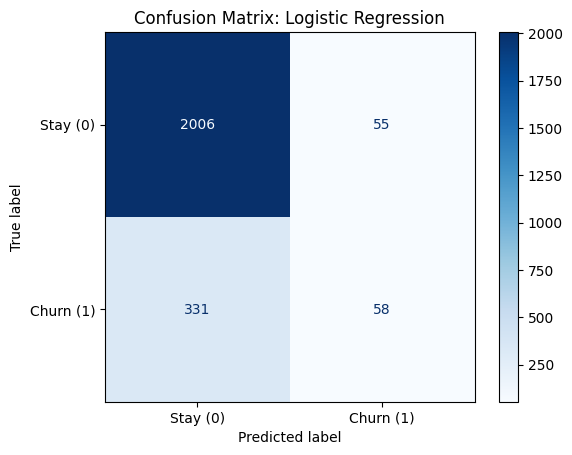


Melatih Model: Random Forest
Accuracy  : 0.8376
Precision : 0.4863
Recall    : 0.4113
F1-score  : 0.4457


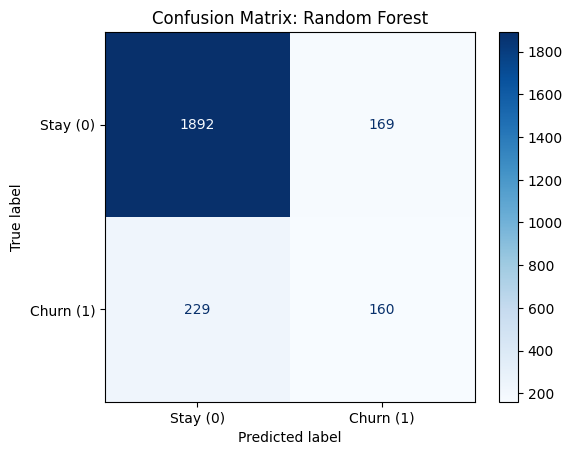


Melatih Model: Voting Classifier


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.8424
Precision : 0.5484
Recall    : 0.0437
F1-score  : 0.0810


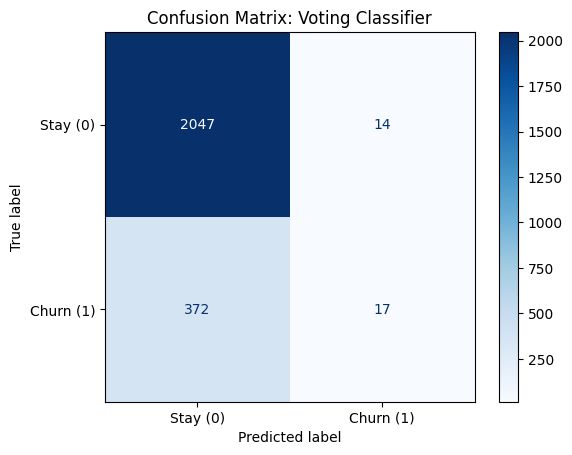

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Menetapkan Target (y) dan Fitur (X) MENTAH
# hanya akan mengambil kolom yang murni berupa angka (numerik).
fitur_numerik = df.select_dtypes(include='number').drop(columns=['churn', 'customer_id']).columns

# Gabungkan sementara untuk membuang baris yang memiliki nilai kosong (NaN)
df_clean = df.dropna(subset=list(fitur_numerik) + ['churn'])

# Pisahkembali setelah baris kosong dibuang
X = df_clean[fitur_numerik]
y = df_clean['churn']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensi Data Latih Baseline (X_train) :", X_train.shape)
print("Dimensi Data Uji Baseline (X_test)    :", X_test.shape)


# 4. Inisialisasi Model (Sesuai Kategori Soal)
# 1. Model Konvensional: Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Model Ensemble Bagging: Random Forest
model_rf = RandomForestClassifier(random_state=42)

# 3. Model Ensemble Voting (Gabungan Logistic Regression, SVM, dan KNN)
model_knn = KNeighborsClassifier()
model_svm = SVC(random_state=42)


model_voting = VotingClassifier(
    estimators=[
        ('lr', model_lr),
        ('knn', model_knn),
        ('svm', model_svm)
    ],
    voting='hard'
)


# Kumpulan model dalam dictionary untuk mempermudah evaluasi otomatis
models = {
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'Voting Classifier': model_voting
}

# 5. Latih Model dan Evaluasi Performa
for name, model in models.items():
    print(f"\n==========================================")
    print(f"Melatih Model: {name}")
    print(f"==========================================")


    # Melatih model secara langsung
    model.fit(X_train, y_train)


    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test)

    # Menghitung metrik evaluasi wajib
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Menampilkan hasil evaluasi
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # Menampilkan Confusion Matrix (Menggunakan visualisasi standar plot)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# **Modeling Dengan Preprocessing**

1. Data duplikat berhasil dihapus.
1.5. Outlier umur negatif berhasil ditangani (diganti median).
2. Fitur ID, Tanggal, dan coupon_code berhasil dibuang.
Missing value berhasil ditangani (Imputasi Median & Modus).
Proses One-Hot Encoding selesai.
Data berhasil dipisah menjadi Train dan Test.
Proses Scaling (Standardization) selesai.

=== HASIL EVALUASI SKENARIO 2 ===

--- Logistic Regression (Prep) ---
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.1609
F1-Score  : 0.2434


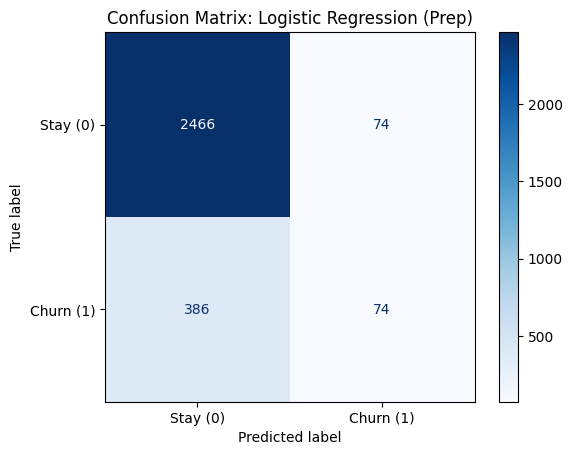


--- Random Forest (Prep) ---
Accuracy  : 0.8487
Precision : 0.5143
Recall    : 0.2348
F1-Score  : 0.3224


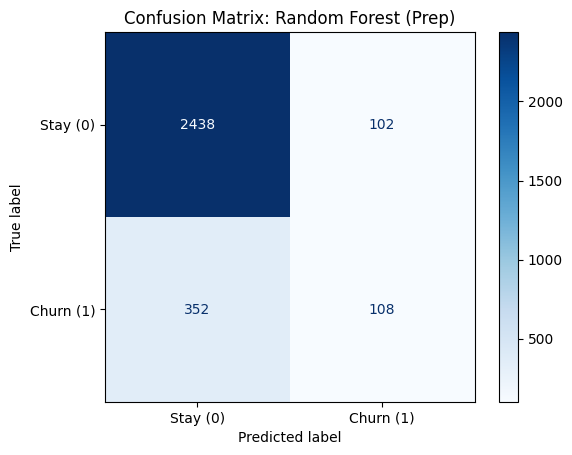


--- Voting Classifier (Prep) ---
Accuracy  : 0.8483
Precision : 0.5758
Recall    : 0.0413
F1-Score  : 0.0771


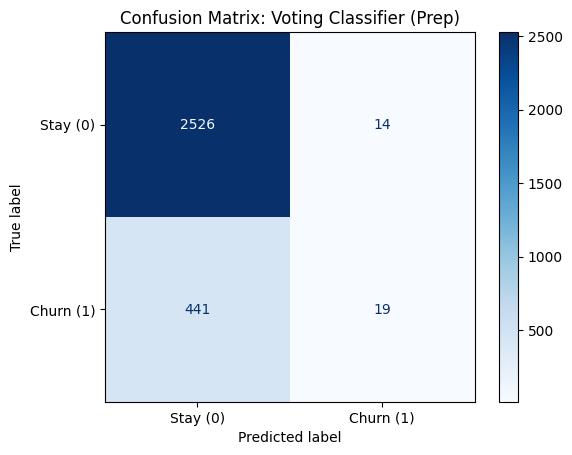

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Prep),0.846667,0.500000,0.160870,0.243421
1,Random Forest (Prep),0.848667,0.514286,0.234783,0.322388
2,Voting Classifier (Prep),0.848333,0.575758,0.041304,0.077079


In [4]:

# C. SKENARIO 2: MODELING DENGAN PREPROCESSING
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Membuat salinan data agar data asli tidak rusak
df_clean = df.copy()


# Penanganan Duplikasi
df_clean = df_clean.drop_duplicates()
print("1. Data duplikat berhasil dihapus.")


# Penanganan Outlier
# Mengganti nilai umur (age) negatif (-4) yang tidak logis dengan median umur
median_age = df_clean['age'].median()
df_clean.loc[df_clean['age'] < 0, 'age'] = median_age
print("1.5. Outlier umur negatif berhasil ditangani (diganti median).")

# Menghapus Fitur Tidak Relevan
# Berdasarkan EDA, 'coupon_code' memiliki missing value > 40%, jadi dibuang.
# Fitur ID dan Tanggal juga dibuang karena bukan prediktor langsung.
kolom_dibuang = ['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date']
df_clean = df_clean.drop(columns=kolom_dibuang, errors='ignore')
print("2. Fitur ID, Tanggal, dan coupon_code berhasil dibuang.")


# Menangani Missing Value
# Numerik diisi dengan Median. Kategorikal diisi dengan Modus.
kolom_numerik = df_clean.select_dtypes(include='number').columns
for col in kolom_numerik:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

kolom_kategori = df_clean.select_dtypes(include='object').columns
for col in kolom_kategori:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
print("Missing value berhasil ditangani (Imputasi Median & Modus).")


# Encoding Fitur Kategorikal
# Mengubah teks menjadi angka menggunakan One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=kolom_kategori, drop_first=True)
print("Proses One-Hot Encoding selesai.")


# Pemisahan Fitur (X) dan Target (y)

X_prep = df_clean.drop(columns=['churn'])
y_prep = df_clean['churn']


# Train-Test Split (Proporsi Sama Persis dengan Skenario 1)
X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)
print("Data berhasil dipisah menjadi Train dan Test.")


# Scaling Fitur (Dilakukan SETELAH Splitting)
scaler = StandardScaler()
# Scaler hanya 'belajar' (fit) dari data latih (X_train)
X_train_scaled = scaler.fit_transform(X_train_prep)
# Scaler hanya 'menerapkan' (transform) pada data uji (X_test)
X_test_scaled = scaler.transform(X_test_prep)
print("Proses Scaling (Standardization) selesai.")

# Inisialisasi Model
model_lr_prep = LogisticRegression(max_iter=1000, random_state=42)
model_rf_prep = RandomForestClassifier(random_state=42)
model_voting_prep = VotingClassifier(
    estimators=[
        ('lr', model_lr_prep),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(random_state=42))
    ],
    voting='hard'
)

models_prep = {
    'Logistic Regression (Prep)': model_lr_prep,
    'Random Forest (Prep)': model_rf_prep,
    'Voting Classifier (Prep)': model_voting_prep
}


# Latih dan Evaluasi Model
print("\n=== HASIL EVALUASI SKENARIO 2 ===")
results_prep = []

for name, model in models_prep.items():
    # Melatih model menggunakan data yang sudah di-scale
    model.fit(X_train_scaled, y_train_prep)

    # Melakukan prediksi
    y_pred = model.predict(X_test_scaled)

    # Menghitung Metrik
    acc = accuracy_score(y_test_prep, y_pred)
    prec = precision_score(y_test_prep, y_pred, zero_division=0)
    rec = recall_score(y_test_prep, y_pred, zero_division=0)
    f1 = f1_score(y_test_prep, y_pred, zero_division=0)

    results_prep.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

    print(f"\n--- {name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # Menampilkan Confusion Matrix Wajib Sesuai Soal
    cm = confusion_matrix(y_test_prep, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Churn (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# Menampilkan Ringkasan
df_results_prep = pd.DataFrame(results_prep)
(df_results_prep)



=== Analisis Feature Importance (Random Forest) ===


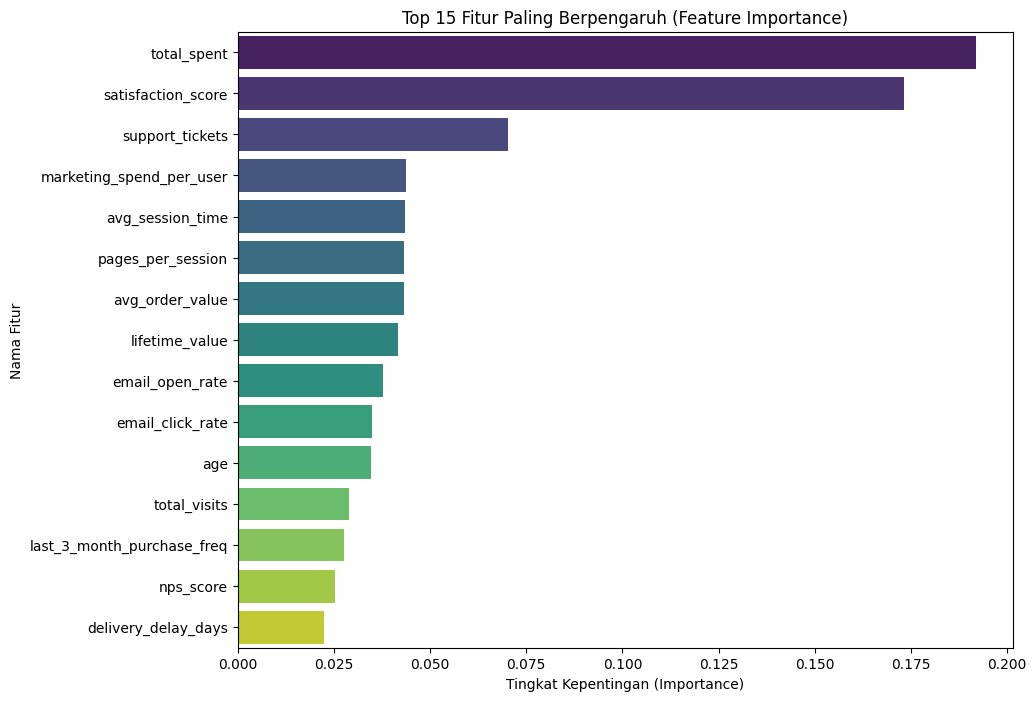

Berdasarkan visualisasi di atas, kita dapat melihat fitur mana saja yang memiliki pengaruh terbesar terhadap churn.


In [5]:

# ANALISIS FEATURE IMPORTANCE
print("\n=== Analisis Feature Importance (Random Forest) ===")
# Menggunakan model Random Forest dari Skenario 2 yang sudah dilatih
importances = model_rf_prep.feature_importances_
fitur_names = X_prep.columns

# Membuat DataFrame untuk memudahkan sorting
fi_df = pd.DataFrame({
    'Fitur': fitur_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=fi_df.head(15), palette='viridis')
plt.title('Top 15 Fitur Paling Berpengaruh (Feature Importance)')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Nama Fitur')
plt.show()

print("Berdasarkan visualisasi di atas, kita dapat melihat fitur mana saja yang memiliki pengaruh terbesar terhadap churn.")


# **Hyperparameter tuning**


=== PROSES HYPERPARAMETER TUNING DIMULAI ===

1. Melakukan Tuning pada Logistic Regression...
   Parameter Terbaik Logistic Regression: {'C': 10.0, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}

2. Melakukan Tuning pada Random Forest...
   Parameter Terbaik Random Forest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

3. Menyiapkan Model KNN...
   Parameter Terbaik KNN: {'n_neighbors': 7, 'weights': 'uniform'}

3.5 Menyiapkan Model SVM...
   Parameter Terbaik SVM: {'C': 1, 'kernel': 'rbf'}

4. Menggabungkan model-model terbaik ke dalam Voting Classifier...

=== HASIL EVALUASI (HYPERPARAMETER TUNING) ===

Model: Logistic Regression (Tuned)
Accuracy  : 0.7523
Precision : 0.3540
Recall    : 0.7457
F1-score  : 0.4801


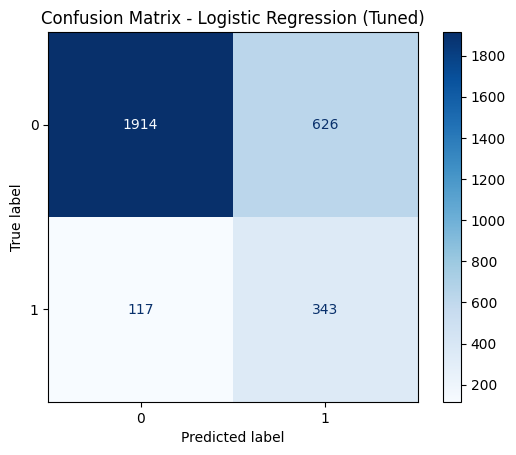


Model: Random Forest (Tuned)
Accuracy  : 0.8540
Precision : 0.5133
Recall    : 0.9196
F1-score  : 0.6589


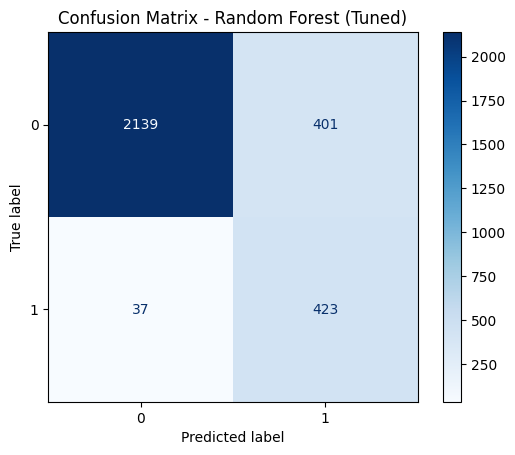


Model: Voting Classifier (Tuned)
Accuracy  : 0.8443
Precision : 0.4821
Recall    : 0.2043
F1-score  : 0.2870


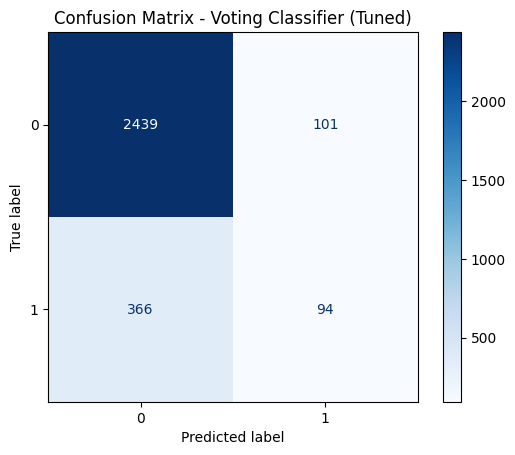


=== TAHAP SKENARIO 3 SELESAI ===

=== Analisis Feature Importance (Model Terbaik: Random Forest Tuned) ===


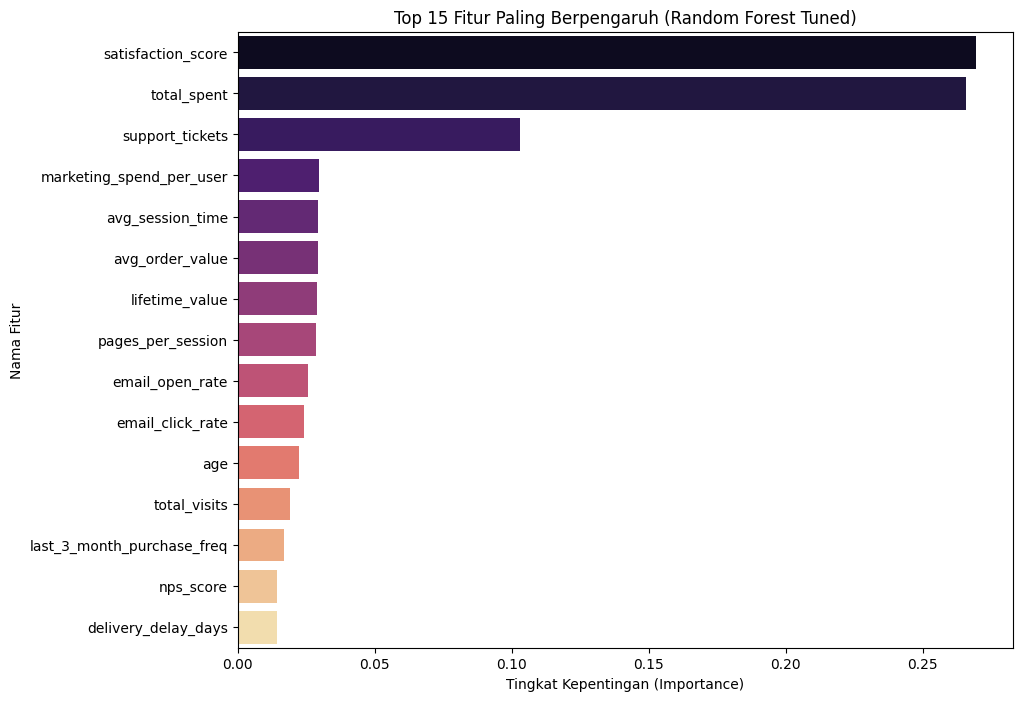

In [6]:

# D. SKENARIO 3: HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

print("\n=== PROSES HYPERPARAMETER TUNING DIMULAI ===")

# 1. Tuning Logistic Regression

print("\n1. Melakukan Tuning pada Logistic Regression...")
# Menyiapkan dictionary parameter yang akan diuji.
# menyertakan class_weight='balanced' untuk menangani data churn yang tidak seimbang.
logreg_params = {
    'C': [0.1, 1.0, 10.0],
    'class_weight': ['balanced'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

# Inisialisasi model dasar
logreg_base = LogisticRegression(random_state=42)

# Mencari parameter terbaik menggunakan GridSearchCV dengan 5 lipatan validasi silang (cv=5)
logreg_grid = GridSearchCV(logreg_base, logreg_params, cv=5, scoring='accuracy', n_jobs=-1)
logreg_grid.fit(X_train_scaled, y_train_prep)

# Mengambil model dengan parameter terbaik
best_logreg = logreg_grid.best_estimator_
print(f"   Parameter Terbaik Logistic Regression: {logreg_grid.best_params_}")


# 2. Tuning Random Forest
print("\n2. Melakukan Tuning pada Random Forest...")
# Menyiapkan parameter untuk Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced'],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)

# Menggunakan GridSearchCV
rf_grid = GridSearchCV(rf_base, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train_prep)

# Mengambil model terbaik
best_rf = rf_grid.best_estimator_
print(f"   Parameter Terbaik Random Forest: {rf_grid.best_params_}")

# 3. Model Konvensional Lainnya (KNN)
# menyiapkan model terbaik untuk KNN
print("\n3. Menyiapkan Model KNN...")
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(knn_base, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train_prep)

best_knn = knn_grid.best_estimator_
print(f"   Parameter Terbaik KNN: {knn_grid.best_params_}")


# 3.5 Tuning SVM
print("\n3.5 Menyiapkan Model SVM...")
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}
svm_base = SVC(probability=True, random_state=42) # Wajib probability=True untuk soft voting
svm_grid = GridSearchCV(svm_base, svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train_prep)
best_svm = svm_grid.best_estimator_
print(f"   Parameter Terbaik SVM: {svm_grid.best_params_}")

# 4. Membangun Voting Classifier dengan Model Terbaik
print("\n4. Menggabungkan model-model terbaik ke dalam Voting Classifier...")
# mnggunakan 'soft' voting agar prediksi mempertimbangkan rata-rata probabilitas
voting_clf_tuned = VotingClassifier(
    estimators=[
        ('logreg', best_logreg),
        ('svm', best_svm),
        ('knn', best_knn)
    ],
    voting='soft'
)

# Melatih Voting Classifier menggunakan data hasil preprocessing
voting_clf_tuned.fit(X_train_scaled, y_train_prep)

# 5. Evaluasi Semua Model yang Sudah Di-Tuning
print("\n=== HASIL EVALUASI (HYPERPARAMETER TUNING) ===")

# Menyimpan model-model terbaik ke dalam dictionary untuk mempermudah perulangan
models_tuned = {
    "Logistic Regression (Tuned)": best_logreg,
    "Random Forest (Tuned)": best_rf,
    "Voting Classifier (Tuned)": voting_clf_tuned
}

# Melakukan iterasi untuk setiap model guna memprediksi dan menampilkan hasil
for name, model in models_tuned.items():
    print(f"\nModel: {name}")

    # Memprediksi data uji
    y_pred = model.predict(X_test_scaled)

    # Menghitung berbagai metrik evaluasi
    acc = accuracy_score(y_test_prep, y_pred)
    prec = precision_score(y_test_prep, y_pred)
    rec = recall_score(y_test_prep, y_pred)
    f1 = f1_score(y_test_prep, y_pred)

    # Menampilkan hasil dengan presisi 4 angka di belakang koma
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # Menampilkan Confusion Matrix secara visual menggunakan ConfusionMatrixDisplay
    cm = confusion_matrix(y_test_prep, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

print("\n=== TAHAP SKENARIO 3 SELESAI ===")

print("\n=== Analisis Feature Importance (Model Terbaik: Random Forest Tuned) ===")
# Menggunakan model best_rf dari hasil GridSearch
importances_tuned = best_rf.feature_importances_

# Karena pakai array X_train_scaled, nama fiturnya kita ambil dari X_prep
fitur_names_tuned = X_prep.columns

fi_tuned_df = pd.DataFrame({
    'Fitur': fitur_names_tuned,
    'Importance': importances_tuned
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=fi_tuned_df.head(15), palette='magma')
plt.title('Top 15 Fitur Paling Berpengaruh (Random Forest Tuned)')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Nama Fitur')
plt.show()
